In [1]:
import struct
import sys
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['figure.figsize']=(6,6)
plt.rcParams['font.weight']='bold'
plt.rcParams['axes.labelweight']='bold'
plt.rcParams['lines.linewidth']=2
plt.rcParams['lines.markeredgewidth']=2
%matplotlib inline
%config InlineBackend.figure_format = "retina"

thincurr_python_path = '/home/clair/repos/install_release'
if thincurr_python_path is not None:
    sys.path.append(os.path.join(thincurr_python_path,'python'))
from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.ThinCurr import ThinCurr
from OpenFUSIONToolkit.ThinCurr.meshing import build_torus_bnorm_grid, ThinCurr_periodic_toroid
from OpenFUSIONToolkit.ThinCurr.sensor import Mirnov, save_sensors
from OpenFUSIONToolkit.ThinCurr.valen import VALENSystem 
from OpenFUSIONToolkit.io import histfile




myOFT = OFT_env(nthreads=2)



#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           1a4bc3c
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Integer Precisions    =    4   8
Float Precisions      =    4   8  10
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------



In [2]:
tw_torus = ThinCurr(myOFT)
tw_torus.setup_model(mesh_file='thincurr_ex-torus.h5',xml_filename='valen_coils_cyl.xml')
tw_torus.setup_io()

Mc = tw_torus.compute_Mcoil()
tw_torus.compute_Lmat()
tw_torus.compute_Rmat()





Creating thin-wall model
  Loading V(t) driver coils
    Masked      4 coils from sensors
  No I(t) driver coils found
  Building holes

  Loading region surface resistivity:
     1  4.0000E-03

  Setup complete:
    # of points    =         2394
    # of edges     =         7182
    # of cells     =         4788
    # of holes     =            2
    # of closures  =            0
    # of Vcoils    =            4
    # of Icoils    =            0
Building coil<->element inductance matrices


    432192 intersecting elements for coil      1
    437323 intersecting elements for coil      2
    455469 intersecting elements for coil      3
    450114 intersecting elements for coil      4
  Time =  0s          
Building coil<->coil inductance matrix
  Time =  0s          
  Vcoil    1: L [H] =   7.0489E-09
  Vcoil    2: L [H] =   7.0489E-09
  Vcoil    3: L [H] =   7.0489E-09
  Vcoil    4: L [H] =   7.0489E-09
Building element<->element self inductance matrix
  Time = 15s          
Building resistivity matrix
  Vcoil    1: R [Ohm] =   1.2041E-07
  Vcoil    2: R [Ohm] =   1.2041E-07
  Vcoil    3: R [Ohm] =   1.2041E-07
  Vcoil    4: R [Ohm] =   1.2041E-07


In [3]:
tw_mode = ThinCurr(myOFT)
tw_mode.setup_model(mesh_file='thincurr_mode.h5', xml_filename='valen_coils_cyl.xml')

with h5py.File('thincurr_mode.h5', 'r+') as h5_file:
    mode_drive = np.asarray(h5_file['thincurr/driver'])



Creating thin-wall model
  Loading V(t) driver coils
    Masked      4 coils from sensors
  No I(t) driver coils found
  Building holes

  Loading region surface resistivity:
     1  4.0000E-03

  Setup complete:
    # of points    =         6320
    # of edges     =        18960
    # of cells     =        12640
    # of holes     =            3
    # of closures  =            2
    # of Vcoils    =            4
    # of Icoils    =            0


In [4]:
import scipy.linalg 
from scipy.linalg import inv 

#tw_torus = tw_torus
#tw_mode = tw_mode

tw_mode.compute_Mcoil()
tw_mode.compute_Lmat()
tw_torus.compute_Mcoil()
#tw_torus.compute_Lmat()

n_vcoils = tw_torus.n_vcoils
torus_start= tw_torus.Lmat.shape[0] - n_vcoils
mode_start = tw_mode.Lmat.shape[0] - n_vcoils 

Lc = tw_torus.Lmat[torus_start:, torus_start:]

Lw = tw_torus.Lmat[:torus_start,:torus_start]
Mwc = tw_torus.Lmat[:torus_start,torus_start:]
Mcw = Mwc.T

Ld_full = tw_mode.Lmat[:mode_start,:mode_start]
Mdc_full = tw_mode.Lmat[:mode_start,mode_start:]

Rc = tw_torus.Lmat[mode_start:, mode_start:]
Rw = tw_torus.Lmat[:torus_start,:torus_start]
Rd_full = tw_mode.Lmat[:mode_start,:mode_start]



Mdw_full = tw_mode.cross_coupling(tw_torus)
Mdw = mode_drive @ Mdw_full[:mode_start,:torus_start]
Mwd = Mdw.T






Building coil<->element inductance matrices


   1169150 intersecting elements for coil      1
   1168390 intersecting elements for coil      2
   1169150 intersecting elements for coil      3
   1168390 intersecting elements for coil      4
  Time =  0s          
Building coil<->coil inductance matrix
  Time =  0s          
  Vcoil    1: L [H] =   7.0489E-09
  Vcoil    2: L [H] =   7.0489E-09
  Vcoil    3: L [H] =   7.0489E-09
  Vcoil    4: L [H] =   7.0489E-09
Building element<->element self inductance matrix
  Time = 55s          
Building coil<->element inductance matrices


    432192 intersecting elements for coil      1
    437323 intersecting elements for coil      2
    455469 intersecting elements for coil      3
    450114 intersecting elements for coil      4
  Time =  0s          
Building coil<->coil inductance matrix
  Time =  0s          
  Vcoil    1: L [H] =   7.0489E-09
  Vcoil    2: L [H] =   7.0489E-09
  Vcoil    3: L [H] =   7.0489E-09
  Vcoil    4: L [H] =   7.0489E-09
Building element<->element mutual inductance matrix
  Time = 47s          


In [5]:
cur_dir = mode_drive
Ld = cur_dir @ Ld_full @ cur_dir.T
Mdc = cur_dir @ Mdc_full
Mcd = Mdc.T


tw_torus.compute_Rmat(copy_out=True)
tw_mode.compute_Rmat(copy_out=True)        

Rc = tw_torus.Rmat[torus_start:, torus_start:]
Rw = tw_torus.Rmat[:torus_start,:torus_start]
Rd_full = tw_mode.Rmat[:mode_start,:mode_start]
Rd = cur_dir @ Rd_full @ cur_dir.T

R = scipy.linalg.block_diag(Rw, Rc, Rd) 


Building resistivity matrix
  Vcoil    1: R [Ohm] =   1.2041E-07
  Vcoil    2: R [Ohm] =   1.2041E-07
  Vcoil    3: R [Ohm] =   1.2041E-07
  Vcoil    4: R [Ohm] =   1.2041E-07
Building resistivity matrix
  Vcoil    1: R [Ohm] =   1.2041E-07
  Vcoil    2: R [Ohm] =   1.2041E-07
  Vcoil    3: R [Ohm] =   1.2041E-07
  Vcoil    4: R [Ohm] =   1.2041E-07


In [6]:
s = -0.15
a = 0.05

P = (-1/(s+a*1j))*np.identity(2)
rho = np.linalg.inv(Ld)@(P-1)


Lw_ef = Lw + Mwd @ rho @ Mdw
Lwd_ef = Mwd + Mwd @ rho @ Ld
Ldw_ef = Mdw + Ld @ rho @ Mdw
Ld_ef = Ld + Ld @ rho @ Ld

Lwc_ef = Mwc + Mwd @ rho @ Mdc
Ldc_ef = Mdc + Ld @ rho @ Mdc
Lcw_ef = Lwc_ef.T 
'''using my version of Lc, assuming the Lc equation in Battey is a typo!!!'''
Lc_ef = Lc + Mcd @ rho @ Mdc
Lcd_ef = Ldc_ef.T 


L = np.block([
    [Lw_ef, Lwc_ef, Lwd_ef],
    [Lcw_ef, Lc_ef, Lcd_ef],
    [Ldw_ef, Ldc_ef, Ld_ef]
])


#return scipy.linalg.eigs(L, -R), right=True)
eig_vals, eig_vecs = scipy.sparse.linalg.eigs(inv(L) @ -R, k=20, which = 'LR')

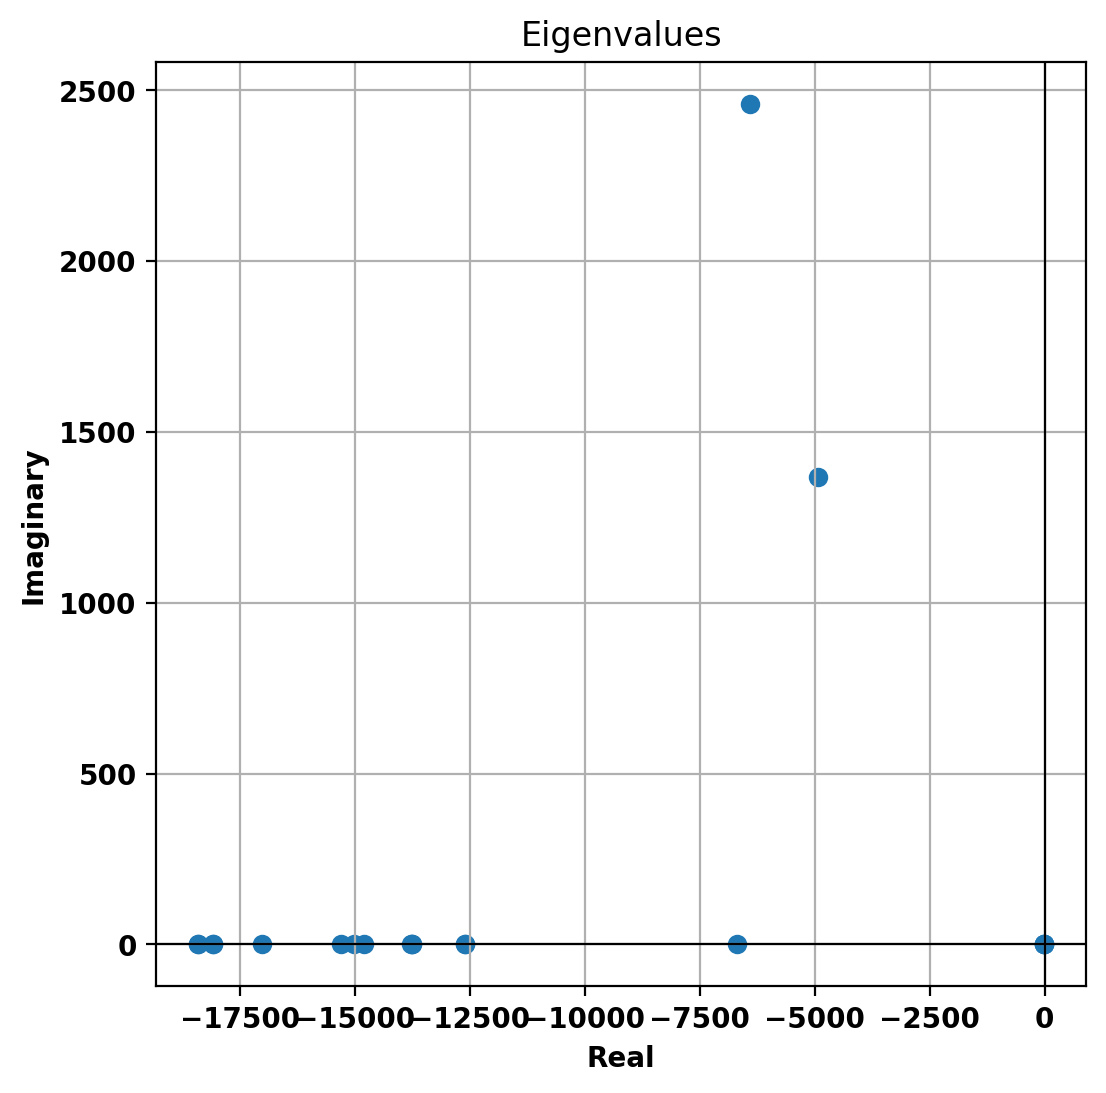

In [7]:
plt.figure()
plt.scatter(eig_vals.real, eig_vals.imag)
plt.axhline(0.0, color="k", linewidth=0.8)
plt.axvline(0.0, color="k", linewidth=0.8)
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Eigenvalues")
plt.grid(True)
plt.show()